Max price is: 116.8, Min price is: 9.33, Mean price is: 57.88402292950034
Max load is: 41015.0, Min load is: 18041.0, Mean load is: 28696.93990521868


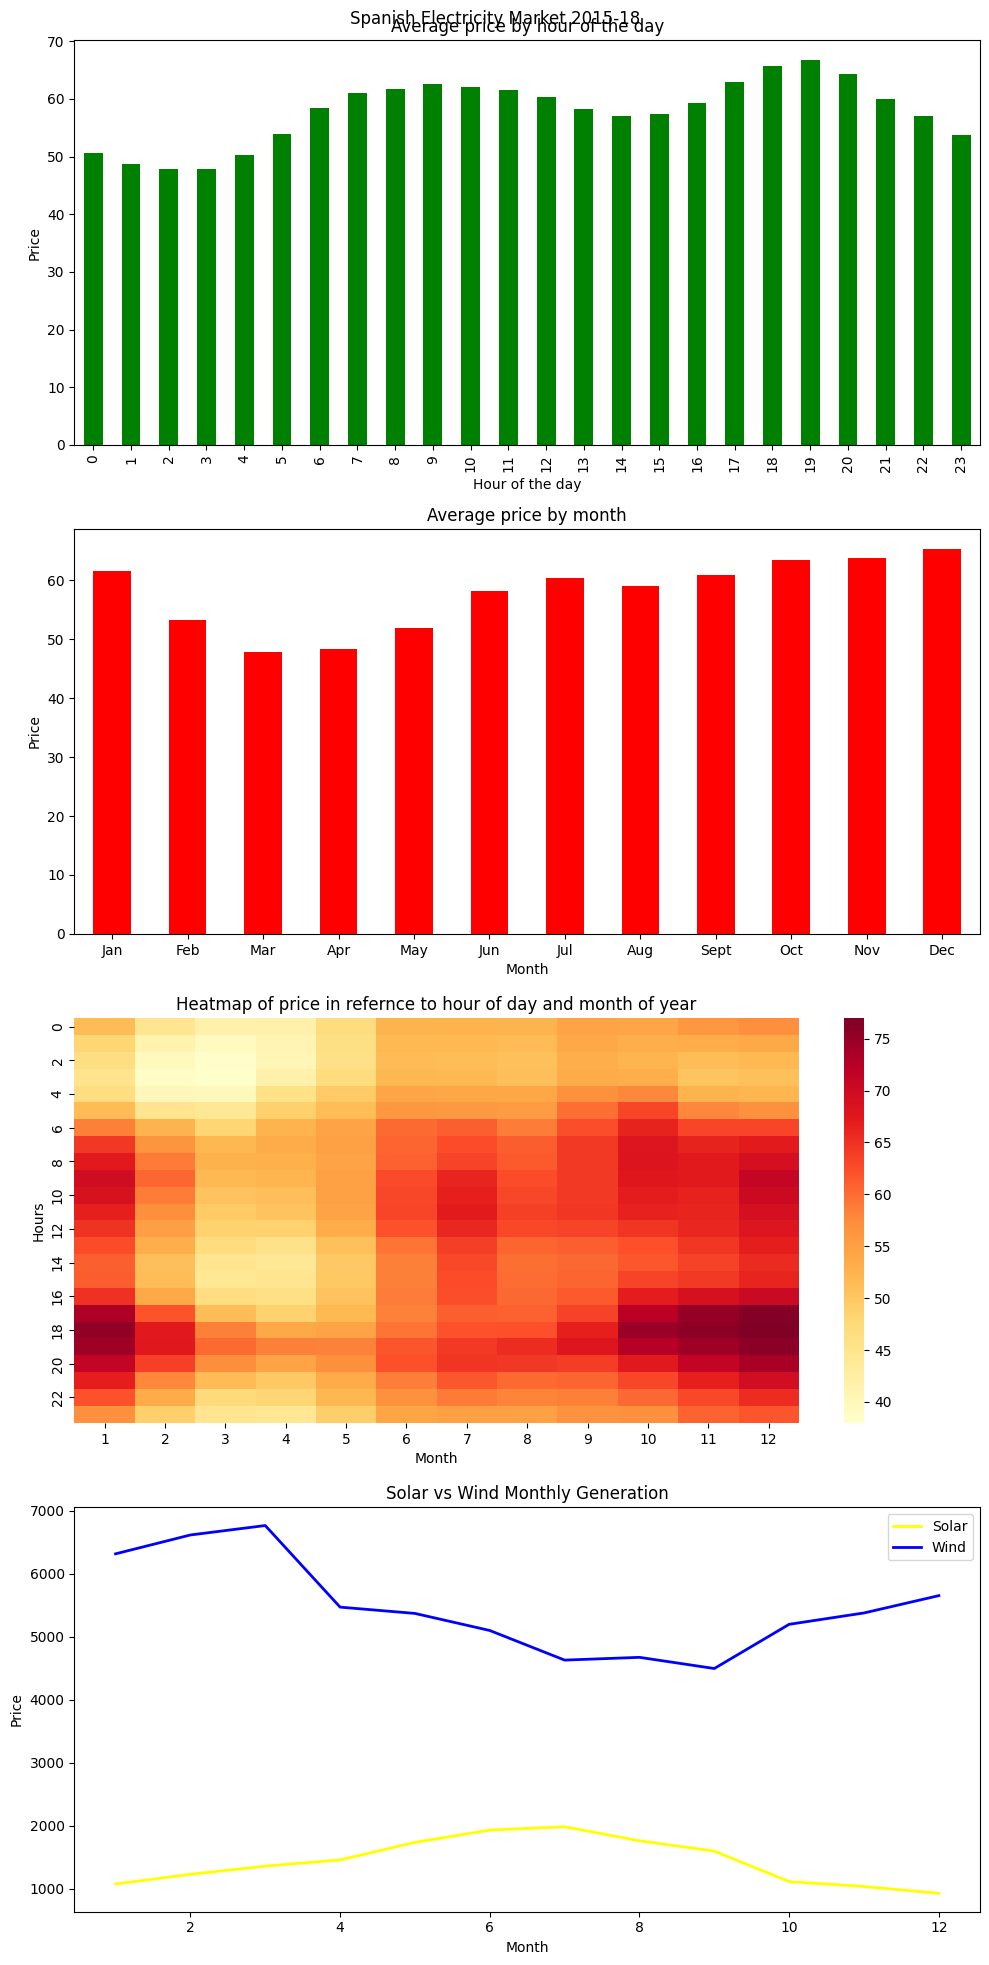

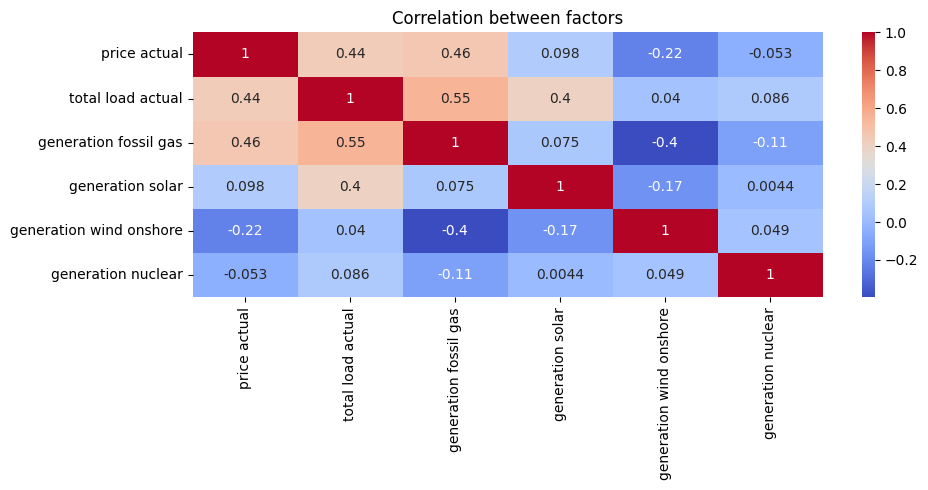

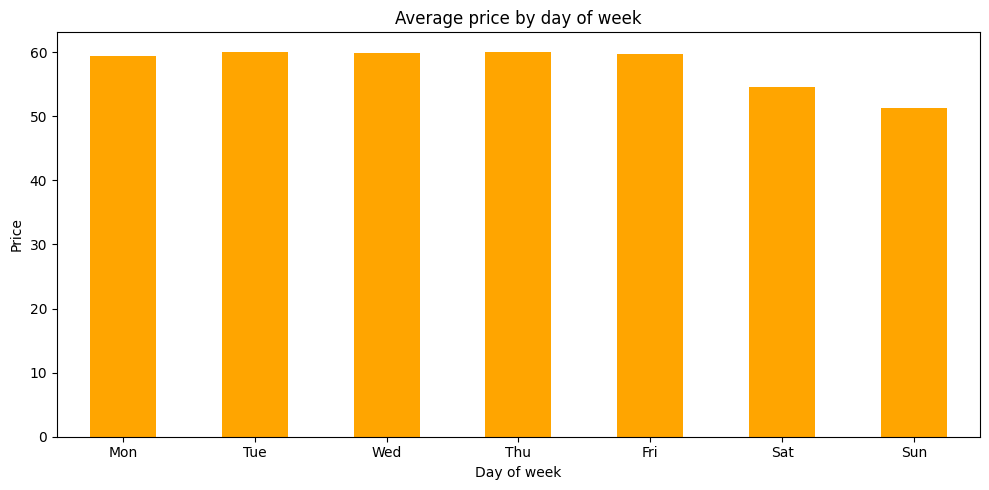

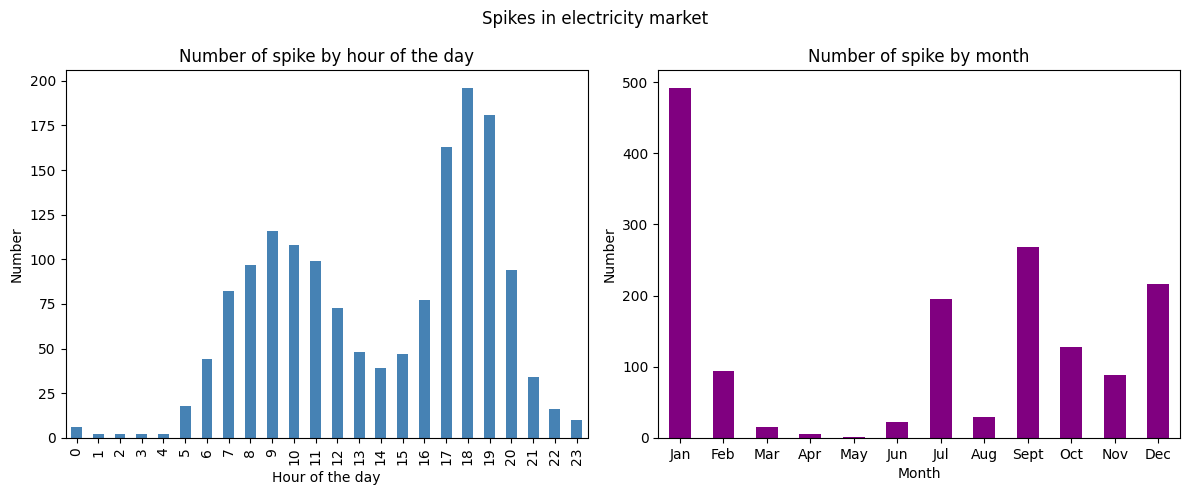

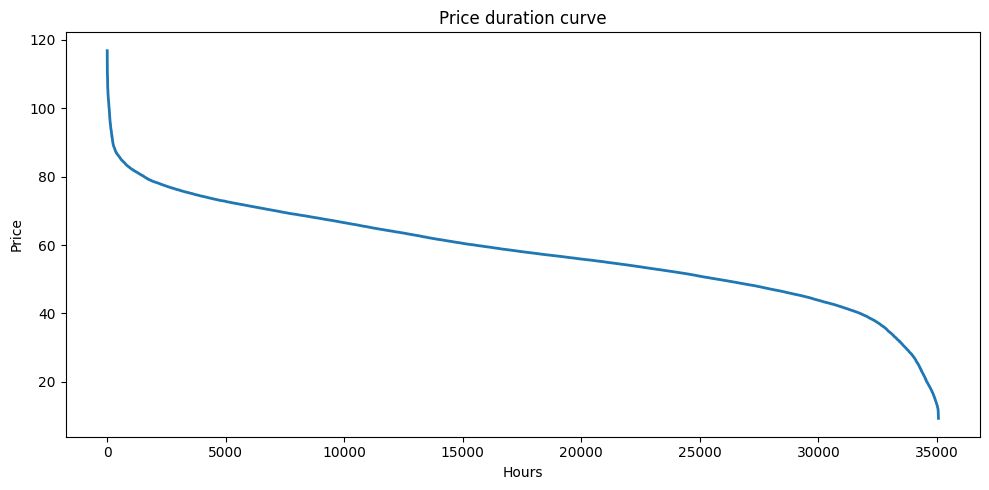

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("energy_dataset.csv") # laod and clean data 
df["time"] = pd.to_datetime(df["time"], utc=True) # convert to usable time from rows
df["hour"] = df["time"].dt.hour # converts eavh row to an hour
df = df.set_index("time") 
df["month"] = df.index.month # setting up a timeline of month for monthly calcs
df["day_of_week"] = df.index.day_of_week # same as above but day of weeks

max_price = df["price actual"].max() # max, min and mean functions, easy
min_price = df["price actual"].min()
mean_price = df["price actual"].mean()
max_load = df["total load actual"].max()
min_load = df["total load actual"].min()
mean_load = df["total load actual"].mean()
print(f"Max price is: {max_price}, Min price is: {min_price}, Mean price is: {mean_price}")
print(f"Max load is: {max_load}, Min load is: {min_load}, Mean load is: {mean_load}")

hourly_avg = df.groupby("hour")["price actual"].mean() # grouping price actual column by hour
monthly_avg = df.groupby("month")["price actual"].mean() # same as above but by month
pivot = df.pivot_table(values= "price actual", index= "hour", columns="month", aggfunc="mean") # this creates a 2D matrix of data of prices in hourXmonth
monthly_solar = df.groupby("month")["generation solar"].mean() # grouping solar energy generation by month
monthly_wind = df.groupby("month")["generation wind onshore"].mean() # same as above but wind onshore

fig, axes = plt.subplots(4, 1, figsize=(10,20)) # subplots

fig.suptitle("Spanish Electricity Market 2015-18", fontsize=12) # the main title

hourly_avg.plot(kind="bar", ax=axes[0], color= "green") # generic plot code
axes[0].set_title("Average price by hour of the day")
axes[0].set_xlabel("Hour of the day")
axes[0].set_ylabel("Price")

monthly_avg.plot(kind="bar", ax=axes[1], color= "red") # same as above
axes[1].set_title("Average price by month")
axes[1].set_xlabel("Month")
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sept","Oct","Nov","Dec"], rotation=0)
axes[1].set_ylabel("Price")

sns.heatmap(pivot, cmap="YlOrRd", fmt=".0f", annot=False, ax=axes[2]) # heatmap code, i copied most of it as i didn't remember
axes[2].set_title("Heatmap of price in refernce to hour of day and month of year")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Hours")

monthly_solar.plot(kind="line", color="yellow", linewidth=2, ax=axes[3]) # generic plot  code
monthly_wind.plot(kind="line", color="blue", linewidth=2, ax=axes[3])
axes[3].set_title("Solar vs Wind Monthly Generation")
axes[3].legend(["Solar", "Wind"])
axes[3].set_xlabel("Month")
axes[3].set_ylabel("Price")

plt.tight_layout()
plt.show()


corr_matrix=df[["price actual", "total load actual", "generation fossil gas", "generation solar", "generation wind onshore", "generation nuclear"]].corr() # matrix of xorrelation between different factors

plt.figure(figsize=(10,5)) # heatmap of correlation matrix
sns.heatmap(corr_matrix, cmap="coolwarm",  annot=True)
plt.title("Correlation between factors")
plt.tight_layout()
plt.show()

price_dow = df.groupby("day_of_week")["price actual"].mean() # grouping price by day of week

price_dow.plot(kind="bar", figsize=(10,5), color="orange")
plt.title("Average price by day of week")
plt.xlabel("Day of week")
plt.xticks(range(7), ["Mon","Tue", "Wed","Thu","Fri","Sat","Sun"], rotation=0)
plt.ylabel("Price")
plt.tight_layout()
plt.show()

price_spike = df[df["price actual"]>80] # new function with only spike>80 data
hour_spike= price_spike.groupby("hour")["price actual"].count() # grouping new spike data by hour
month_spike= price_spike.groupby("month")["price actual"].count() # same but by month

fig, axes= plt.subplots(1,2,figsize=(12,5)) # subplots

fig.suptitle("Spikes in electricity market", fontsize=12)

hour_spike.plot(kind="bar", ax=axes[0], color= "steelblue") #genereic plot code
axes[0].set_title("Number of spike by hour of the day")
axes[0].set_xlabel("Hour of the day")
axes[0].set_ylabel("Number")

month_spike.plot(kind="bar", ax=axes[1], color= "purple") # same as above
axes[1].set_title("Number of spike by month")
axes[1].set_xlabel("Month")
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sept","Oct","Nov","Dec"], rotation=0)
axes[1].set_ylabel("Number")

plt.tight_layout()
plt.show()

sorted_prices = df["price actual"].sort_values(ascending=False).reset_index(drop=True)

sorted_prices.plot(kind="line", figsize=(10,5), linewidth=2)
plt.title("Price duration curve")
plt.xlabel("Hours")
plt.ylabel("Price")
plt.tight_layout()
plt.show()